# Plant village disease classification
### Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

### Set Path

In [2]:
path = "C:/Users/jalaj/OneDrive/Desktop/Interview preparation/Kaggle data/Plantvillage/PlantVillage"

### Data Preprocessing

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

### Load Data

In [5]:
train_data = datagen.flow_from_directory(
    path,
    target_size=(128,128),
    batch_size=32,
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(128,128),
    batch_size=32,
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


### Check class

In [6]:
print(train_data.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


### Build model

In [7]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes,activation='softmax')
])

### Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model 

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

C:\Users\jalaj\anaconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 370s 708ms/step - accuracy: 0.4825 - loss: 1.6778 - val_accuracy: 0.7770 - val_loss: 0.7090
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 131s 253ms/step - accuracy: 0.8355 - loss: 0.4913 - val_accuracy: 0.8641 - val_loss: 0.4230
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 122s 235ms/step - accuracy: 0.9181 - loss: 0.2486 - val_accuracy: 0.8741 - val_loss: 0.3838
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 122s 236ms/step - accuracy: 0.9531 - loss: 0.1500 - val_accuracy: 0.8719 - val_loss: 0.4012
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 123s 238ms/step - accuracy: 0.9743 - loss: 0.0782 - val_accuracy: 0.8814 - val_loss: 0.4161


### Check Accuracy

In [10]:
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['val_accuracy'])

Training Accuracy: [0.6387745141983032, 0.8485105633735657, 0.9189270734786987, 0.9505327939987183, 0.9696052074432373]
Validation Accuracy: [0.7770499587059021, 0.8641436100006104, 0.8740902543067932, 0.8719068169593811, 0.8813682794570923]


### Prediction(new image)

In [12]:
img_path = "C:/Users/jalaj/OneDrive/Desktop/Interview preparation/Kaggle data/Test image/tomatoleaf.jpg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


### Get class name

In [13]:
class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

Predicted Disease: Tomato_Late_blight


### Show image & result

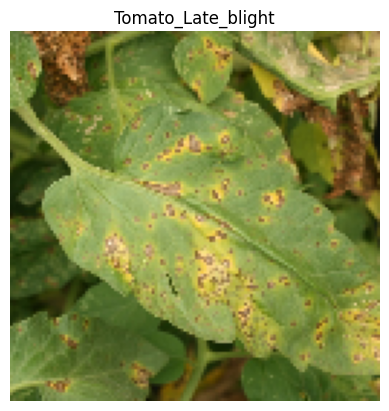

In [14]:
plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()